<a href="https://colab.research.google.com/github/danielmogo25/Proyecto-UNAL-ChatMP3/blob/main/Chat_mp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
#importamos las librerias que vamos a usar
import requests
import sqlite3
from IPython.display import Audio
from IPython.display import Image, display
import pandas as pd


In [67]:
def obtener_o_crear_id(cur, tabla, nombre):
    """
    Inserta 'nombre' en 'tabla' si no existe, y devuelve su id.
    Sirve para Artista, Album y Genero (todas tienen la misma estructura: id, nombre).
    """
    cur.execute(f"INSERT OR IGNORE INTO {tabla} (nombre) VALUES (?)", (nombre,))
    cur.execute(f"SELECT id FROM {tabla} WHERE nombre = ?", (nombre,))
    return cur.fetchone()[0]

In [68]:
def insertar_cancion(cur, dato):
    """
    Inserta una canción (y resuelve artista/álbum/género) en la base de datos.

    Args:
        cur: cursor de sqlite3.
        dato (dict): diccionario con los datos de la canción (de la API).

    Returns:
        bool: True si se insertó correctamente, False si falló.
    """
    try:
        titulo = dato.get('trackName')
        nombre_artista = dato.get('artistName')
        nombre_album = dato.get('collectionName')
        nombre_genero = dato.get('primaryGenreName')
        preview = dato.get('previewUrl')
        milisegundos = dato.get('trackTimeMillis') or 0
        fecha_raw = dato.get('releaseDate')
        fecha = int(fecha_raw[:4]) if fecha_raw else None
    except (ValueError, TypeError) as error:
        print(f" No se pudo interpretar los datos de la canción: {error}")
        return False

    if not titulo:
        print(" El registro no tiene título, se omite.")
        return False

    try:
        # 1. Resolver artista, album y genero a sus ids
        artista_id = obtener_o_crear_id(cur, "Artista", nombre_artista)
        album_id = obtener_o_crear_id(cur, "Album", nombre_album)
        genero_id = obtener_o_crear_id(cur, "Genero", nombre_genero)

        # 2. Insertar la cancion usando esos ids
        cur.execute('''
            INSERT OR IGNORE INTO Track (titulo, artista_id, album_id, genero_id, duracion, fecha, preview)
            VALUES (?, ?, ?, ?, ?, ?, ?)
        ''', (titulo, artista_id, album_id, genero_id, milisegundos, fecha, preview))
        return True
    except sqlite3.Error as error:
        print(f" No se pudo guardar '{titulo}' en la base de datos: {error}")
        return False

In [69]:

#Creacion base de datos
conn = sqlite3.connect('base_datos_chat_mp3.sqlite')
cur=conn.cursor()
cur.executescript('''
DROP TABLE IF EXISTS Track;
DROP TABLE IF EXISTS Artista;
DROP TABLE IF EXISTS Genero;
DROP TABLE IF EXISTS Album;

CREATE TABLE Track(
id INTEGER NOT NULL PRIMARY KEY AUTOINCREMENT UNIQUE,
titulo TEXT UNIQUE,
artista_id INTEGER,
album_id INTEGER,
genero_id INTEGER,
duracion INTEGER,
fecha INTEGER,
preview TEXT
);
CREATE TABLE Artista(
id INTEGER NOT NULL PRIMARY KEY AUTOINCREMENT UNIQUE,
nombre TEXT UNIQUE
);
CREATE TABLE Album(
id INTEGER NOT NULL PRIMARY KEY AUTOINCREMENT UNIQUE,
nombre TEXT UNIQUE
);
CREATE TABLE Genero(
id INTEGER NOT NULL PRIMARY KEY AUTOINCREMENT UNIQUE,
nombre TEXT UNIQUE
)
''')
conn.commit()

In [70]:
cur.execute('''
    SELECT Track.titulo, Artista.nombre, Album.nombre, Genero.nombre, Track.duracion
    FROM Track
    JOIN Artista ON Track.artista_id = Artista.id
    JOIN Album ON Track.album_id = Album.id
    JOIN Genero ON Track.genero_id = Genero.id
''')

for fila in cur.fetchall():
    print(fila)

In [71]:
def descargar_imagen(url,nombre_archivo):
  """
    Descarga un archivo binario desde una URL y lo guarda en disco.

    Args:
        url (str): URL del archivo a descargar.
        nombre_archivo (str): nombre con el que se guardará localmente.

    Returns:
        bool: True si la descarga fue exitosa, False si falló.
    """

  try:
      respuesta = requests.get(url, stream=True, timeout=10)
      respuesta.raise_for_status()

      with open(nombre_archivo, "wb") as archivo:
          for bloque in respuesta.iter_content(chunk_size=8192):
              archivo.write(bloque)

      print(f" Archivo guardado como '{nombre_archivo}'")
      return True

  except requests.exceptions.Timeout:
      print(" La descarga tardó demasiado y se canceló.")
  except requests.exceptions.RequestException as error:
      print(f" No se pudo descargar el archivo: {error}")

  return False

In [72]:
def buscador_por_termino(termino, limite):
    url = "https://itunes.apple.com/search"
    params = {
        "term": termino,
        "media": "music",
        "entity": "song",
        "limit": limite
    }
    try:
        respuesta_1 = requests.get(url, params=params, timeout=10)
        respuesta_1.raise_for_status()
    except requests.exceptions.Timeout:
        print(" La búsqueda tardó demasiado y se canceló.")
        return
    except requests.exceptions.RequestException as error:
        print(f" No se pudo realizar la búsqueda: {error}")
        return

    print("CODIGO DE ESTADO", respuesta_1.status_code)
    resultados = respuesta_1.json()["results"]

    for dato in resultados:
        titulo = dato.get('trackName')
        album = dato.get("collectionName")
        artista = dato.get('artistName')
        preview = dato.get('previewUrl')
        fecha = int(dato.get('releaseDate')[:4])
        genero = dato.get('primaryGenreName')

        milisegundos = dato.get('trackTimeMillis')
        minutos = milisegundos // 60000
        segundos = (milisegundos % 60000) // 1000
        duracion = f"{minutos}:{segundos:02d}"

        imagen_url = dato.get('artworkUrl100')
        nombre_limpio = "".join(c for c in titulo if c.isalnum() or c in (" ", "_", "-")).rstrip()
        archivo_local = f"{nombre_limpio}.jpg"
        descargar_imagen(imagen_url, archivo_local)

        print("=" * 50)
        print(f"TITULO:{titulo}\nALBUM:{album}\nARTISTA:{artista}\nGENERO:{genero}\nDURACION:{duracion}\nPREVIEW LINK:{preview}\nAÑO SALIDA:{fecha}")
        display(Image(archivo_local))

        nombre_archivo = f"{nombre_limpio}Preview.m4a"
        try:
            info = requests.get(preview, timeout=10)
            info.raise_for_status()
            with open(nombre_archivo, "wb") as archi:
                archi.write(info.content)
            display(Audio(nombre_archivo))
        except requests.exceptions.Timeout:
            print(" La descarga del preview tardó demasiado y se canceló.")
        except requests.exceptions.RequestException as error:
            print(f" No se pudo descargar el preview: {error}")

        # --- Guardar en la base de datos ---
        insertar_cancion(cur, dato)

    conn.commit()   # confirma todas las inserciones de esta búsqueda

CODIGO DE ESTADO 200
 Archivo guardado como 'Lose Yourself.jpg'
TITULO:Lose Yourself
ALBUM:8 Mile (Music from and Inspired By the Motion Picture)
ARTISTA:Eminem
GENERO:Soundtrack
DURACION:5:21
PREVIEW LINK:https://audio-ssl.itunes.apple.com/itunes-assets/AudioPreview125/v4/62/0a/a5/620aa56f-189e-708a-80f0-cebdada3872e/mzaf_7131619873177773332.plus.aac.p.m4a
AÑO SALIDA:2002


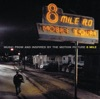

In [82]:
buscador_por_termino("eminem", 1)

In [83]:
df = pd.read_sql_query('''
    SELECT
        Track.id,
        Track.titulo,
        Artista.nombre AS artista,
        Album.nombre AS album,
        Genero.nombre AS genero,
        Track.duracion,
        Track.fecha,
        Track.preview
    FROM Track
    JOIN Artista ON Track.artista_id = Artista.id
    JOIN Album ON Track.album_id = Album.id
    JOIN Genero ON Track.genero_id = Genero.id
''', conn)

display(df)

,id,titulo,artista,album,genero,duracion,fecha,preview
0,1,Back In Black,AC/DC,Back In Black,Hard Rock,256000,1980,https://audio-ssl.itunes.apple.com/itunes-asse...
1,2,Thriller,Michael Jackson,Thriller,Pop,358807,1982,https://audio-ssl.itunes.apple.com/itunes-asse...
2,3,Beat It,Michael Jackson,Thriller,Pop,258297,1982,https://audio-ssl.itunes.apple.com/itunes-asse...
3,4,Off the Wall,Michael Jackson,Off the Wall,Pop,245779,1979,https://audio-ssl.itunes.apple.com/itunes-asse...
4,5,Mortal Man,Kendrick Lamar,To Pimp a Butterfly,Hip-Hop/Rap,727102,2015,https://audio-ssl.itunes.apple.com/itunes-asse...
5,6,Lose Yourself,Eminem,8 Mile (Music from and Inspired By the Motion ...,Soundtrack,321960,2002,https://audio-ssl.itunes.apple.com/itunes-asse...


In [57]:
#url API Searh endpoint
url="https://itunes.apple.com/search"
#Parametros necesarios (term=your+search+query )
#url API lookup endpoint para sacar la meta data
url_search_point="https://itunes.apple.com/lookup"
#
for dato in resultados:
    titulo=dato.get()

NameError: name 'resultados' is not defined